# EDA — Spain 2027 EV Charging Network
## IE Sustainability Datathon 2026 · Iberdrola Challenge

Full exploratory data analysis across all mandatory datasets (M1–M3) and grid capacity.

| Section | Dataset | Key question |
|---|---|---|
| 1 | M1 Road Network | Which roads and how long? |
| 2 | M2 Charging Baseline | What infrastructure exists nationally? |
| 3 | M2 Interurban & Coverage Gap | How well covered are interurban roads? |
| 4 | M3 BEV Fleet Projection | How many EVs by 2027? |
| 5 | Cross-Dataset Synthesis | What is the 2027 supply–demand gap? |
| 6 | Grid Capacity (Endesa) | Can the grid support new HPC hubs? |
| 7 | National Grid (REE) | What is EV load as % of national demand? |
| 8 | Summary | All key KPIs in one place |

---
## 0. Setup

In [36]:
import os, json, warnings, glob
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import requests
from pyproj import Transformer
warnings.filterwarnings('ignore')

# ── Colab: clone repo if needed ───────────────────────────────────────────
IN_COLAB = 'google.colab' in __import__('sys').modules
if IN_COLAB:
    import subprocess
    if not os.path.isdir('IberdrolaDatathon'):
        subprocess.run(['git','clone','https://github.com/NOSIEMPRE/IberdrolaDatathon.git'], check=True)
    os.chdir('IberdrolaDatathon/Datathon')

# ── Base path detection ───────────────────────────────────────────────────
for _d in ['.', '..']:
    if os.path.isdir(os.path.join(_d, 'Data')):
        BASE = os.path.abspath(_d); break
else:
    raise FileNotFoundError('Cannot find Data/ folder')

RTIG_PATH     = f'{BASE}/Data/raw/road_routes_spain/carreteras_RTIG.geojson'
M2_ALL        = f'{BASE}/Data/interim/m2_charging_sites_all.csv'
M2_INTERURBAN = f'{BASE}/Data/interim/m2_charging_sites_interurban.csv'
M2_COVERAGE   = f'{BASE}/Data/interim/m2_road_coverage.csv'
M3_PARQUET    = f'{BASE}/Data/raw/ev_fleet_projections_datosgob/parquet'
M3_JSON       = f'{BASE}/Data/processed/m3_ev_projection.json'
ENDESA_CSV    = f'{BASE}/Data/external/grid_capacity_endesa/endesa_demanda_2026_03.csv'

print(f'BASE = {BASE}')
for label, path in [
    ('RTIG geojson',      RTIG_PATH),
    ('M2 all sites',      M2_ALL),
    ('M2 interurban',     M2_INTERURBAN),
    ('M2 road coverage',  M2_COVERAGE),
    ('M3 parquets',       M3_PARQUET),
    ('M3 projection JSON',M3_JSON),
    ('Endesa CSV',        ENDESA_CSV),
]:
    exists = os.path.isdir(path) if 'parquet' in label else os.path.isfile(path)
    print(f'  {"OK" if exists else "MISSING":7s} {label}')

BASE = /Users/isabelwu/Desktop/Project/IberdrolaDatathon/Datathon
  OK      RTIG geojson
  OK      M2 all sites
  OK      M2 interurban
  OK      M2 road coverage
  MISSING M3 parquets
  OK      M3 projection JSON
  OK      Endesa CSV


---
## 1. Road Network — RTIG Interurban Roads (M1)

In [52]:
roads = gpd.read_file(RTIG_PATH)

total_km = roads['length_m'].sum() / 1000
print(f'Segments   : {len(roads):,}')
print(f'Total km   : {total_km:,.0f} km')
print()
print('Road type breakdown:')
vc = roads['Tipo_de_via'].value_counts()
km = roads.groupby('Tipo_de_via')['length_m'].sum().div(1000).round(0).astype(int)
for t in vc.index:
    print(f'  {t:<35s}  {vc[t]:>4} segs  {km[t]:>6,} km')

Segments   : 1,535
Total km   : 29,050 km

Road type breakdown:
  Carretera convencional                722 segs  14,290 km
  Autopista libre\Autovía               534 segs  11,799 km
  Multicarril                           189 segs     567 km
  Autopista peaje                        79 segs   2,132 km


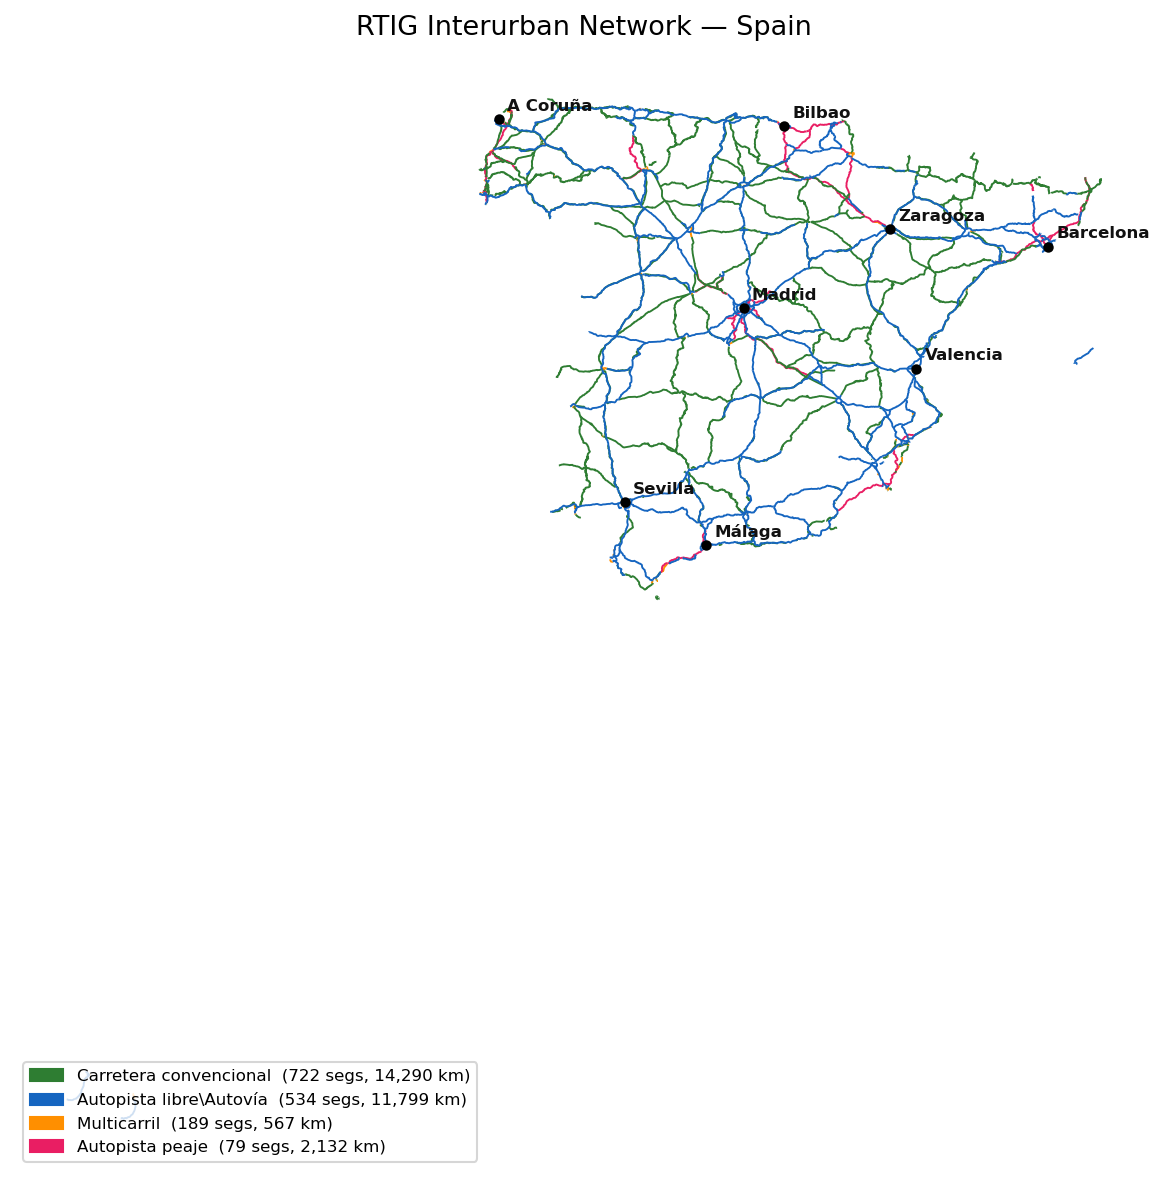

In [67]:
# Map of RTIG interurban network colored by road type
fig, ax = plt.subplots(figsize=(10, 8), dpi=150)

TYPE_COLORS = {
    'Autopista libre\\Autovía': '#1565C0',
    'Autopista peaje':          '#E91E63',
    'Carretera convencional':   '#2E7D32',
    'Multicarril':              '#FF8F00',
}
default_color = '#9E9E9E'

for tipo in roads['Tipo_de_via'].dropna().unique():
    roads[roads['Tipo_de_via'] == tipo].plot(
        ax=ax, color=TYPE_COLORS.get(tipo, default_color), linewidth=0.9)

# City labels
cities = {
    'Madrid':    (-3.70, 40.42),
    'Barcelona': (2.15,  41.38),
    'Valencia':  (-0.38, 39.47),
    'Sevilla':   (-5.99, 37.39),
    'Bilbao':    (-2.93, 43.26),
    'Zaragoza':  (-0.88, 41.65),
    'Málaga':    (-4.42, 36.72),
    'A Coruña':  (-8.41, 43.37),
}
for city, (lon, lat) in cities.items():
    ax.plot(lon, lat, 'o', color='black', markersize=4, zorder=5)
    ax.annotate(city, xy=(lon, lat), xytext=(4, 4),
                textcoords='offset points', fontsize=8,
                fontweight='bold', color='#111111')

handles = [mpatches.Patch(color=TYPE_COLORS.get(t, default_color),
                          label=f'{t}  ({vc[t]} segs, {km[t]:,} km)')
           for t in vc.index]
ax.legend(handles=handles, fontsize=8, loc='lower left')
ax.set_title('RTIG Interurban Network — Spain', fontsize=13)
ax.axis('off')
plt.tight_layout()
plt.show()


Autopistas and autovías (13,931 km, 48%) are the primary target for HPC deployment given their high-speed, long-distance traffic profile. Carreteras convencionales (14,290 km, 49%) are secondary priority. The network has a clear radial structure centred on Madrid, meaning a small number of well-placed hubs along the main corridors to Barcelona, Valencia, Sevilla, and Bilbao would cover the majority of long-distance journeys.

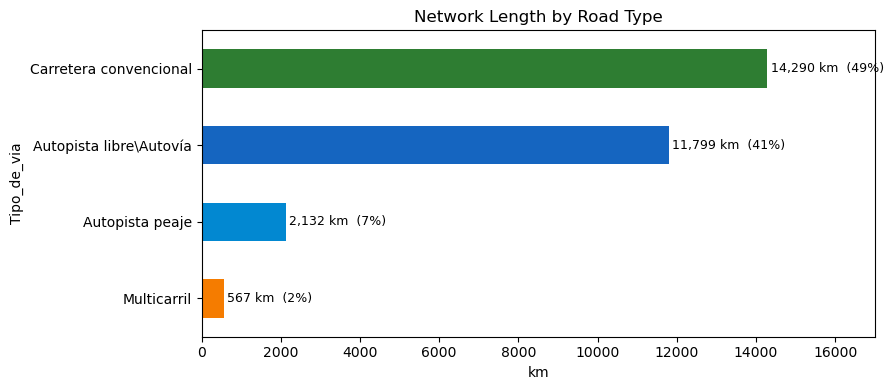

In [55]:
# Network length by road type
fig, ax = plt.subplots(figsize=(9, 4))
km_sorted = km.sort_values()
colors_bar = [TYPE_COLORS.get(t, default_color) for t in km_sorted.index]
km_sorted.plot(kind='barh', ax=ax, color=colors_bar)
ax.set_xlabel('km')
ax.set_title('Network Length by Road Type')
for i, v in enumerate(km_sorted):
    ax.text(v + 80, i, f'{v:,} km  ({v/total_km*100:.0f}%)', va='center', fontsize=9)
ax.set_xlim(0, 17000)
plt.tight_layout()
plt.show()

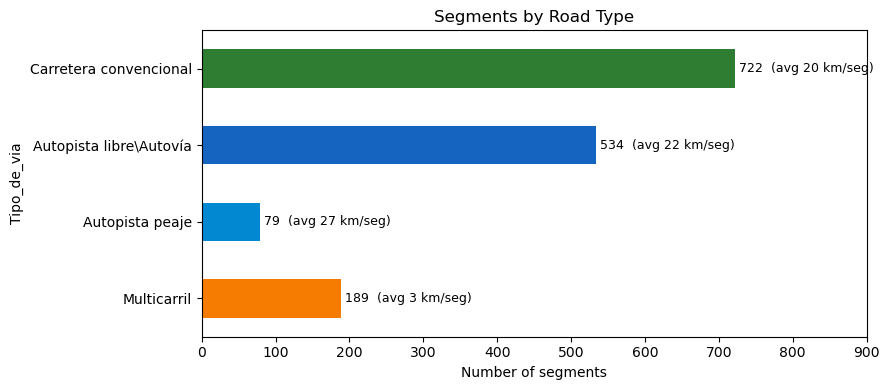

In [57]:
# Segments by road type
fig, ax = plt.subplots(figsize=(9, 4))
vc_sorted = vc.reindex(km_sorted.index)
vc_sorted.plot(kind='barh', ax=ax, color=colors_bar)
ax.set_xlabel('Number of segments')
ax.set_title('Segments by Road Type')
for i, v in enumerate(vc_sorted):
    avg_km = km_sorted.iloc[i] / v
    ax.text(v + 5, i, f'{v}  (avg {avg_km:.0f} km/seg)', va='center', fontsize=9)
ax.set_xlim(0, 900)
plt.tight_layout()
plt.show()

**Road Network Baseline**

Spain's eligible interurban network comprises 1,535 segments spanning 29,050 km in total. The network is dominated by two categories: carreteras convencionales (14,290 km, 49%) and autopistas/autovías libres (11,799 km, 41%), together accounting for 90% of the total eligible network. Autopistas de peaje add a further 2,132 km (7%), while multicarril segments contribute only 567 km (2%).

From a charging infrastructure planning perspective, autopistas and autovías are the primary target. Despite having fewer segments (613 total across both toll and free categories), they cover 13,931 km of high-speed, long-distance corridors where drivers have the strongest need for reliable rapid charging. Their average segment length (11,799/534 = ~22 km for free motorways) also means fewer but longer stretches between potential hub locations.

Carreteras convencionales, while the longest category by km, are lower priority for HPC deployment. Their 722 segments average only ~20 km each, suggesting a more fragmented, lower-speed network where urban charging and destination charging can partially substitute for interurban hubs.

This road type distribution directly shapes the charging network design recommendations: HPC hubs should be concentrated on the autopista/autovía corridors, with secondary coverage extending to carreteras convencionales where the coverage gap analysis (Section 3) identifies underserved stretches.

---
## 2. EV Charging Sites — National Baseline (M2)

In [58]:
# Load national charging sites dataset and compute key power statistics
if os.path.isfile(M2_ALL):
    df_all = pd.read_csv(M2_ALL)
else:
    df_all = pd.read_csv(M2_INTERURBAN)
    print('National CSV not found — using interurban only')

gdf_all = gpd.GeoDataFrame(
    df_all,
    geometry=gpd.points_from_xy(df_all['longitude'], df_all['latitude']),
    crs='EPSG:4326')

bins   = [0, 7.4, 22, 50, 100, 150, 250, 350, 1000]
labels = ['≤7.4 (AC slow)', '7.4–22 (AC)', '22–50 (AC fast)',
          '50–100 (DC)', '100–150 (DC fast)', '150–250 (HPC)',
          '250–350 (HPC+)', '>350 (Ultra)']
gdf_all['power_band'] = pd.cut(gdf_all['max_power_kw'], bins=bins, labels=labels)

print(f'Total sites        : {len(gdf_all):,}')
print(f'DC fast (≥50 kW)   : {(gdf_all["max_power_kw"] >= 50).sum():,}  ({(gdf_all["max_power_kw"] >= 50).mean()*100:.1f}%)')
print(f'HPC (≥150 kW)      : {(gdf_all["max_power_kw"] >= 150).sum():,}  ({(gdf_all["max_power_kw"] >= 150).mean()*100:.1f}%)')
print(f'Avg connectors/site: {gdf_all["n_refill_points"].mean():.1f}')


Total sites        : 12,074
DC fast (≥50 kW)   : 5,338  (44.2%)
HPC (≥150 kW)      : 1,065  (8.8%)
Avg connectors/site: 3.0


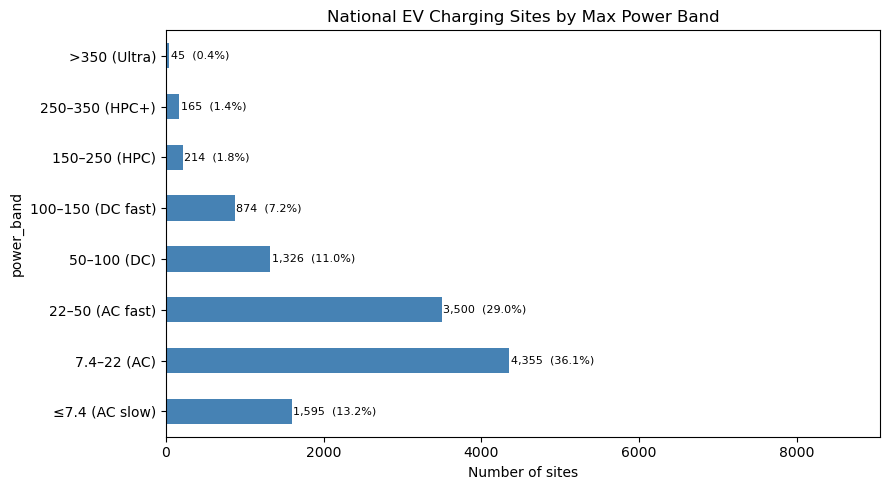

In [ ]:
# Power band distribution — shows proportion of sites at each charging speed tier
fig, ax = plt.subplots(figsize=(9, 5))
gdf_all['power_band'].value_counts().sort_index().plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('National EV Charging Sites by Max Power Band')
ax.set_xlabel('Number of sites')
total = len(gdf_all)
for i, v in enumerate(gdf_all['power_band'].value_counts().sort_index()):
    ax.text(v + 20, i, f'{v:,}  ({v/total*100:.1f}%)', va='center', fontsize=8)
ax.set_xlim(0, total * 0.75)
plt.tight_layout()
plt.show()

Top 15 operators control 86.9% of all sites


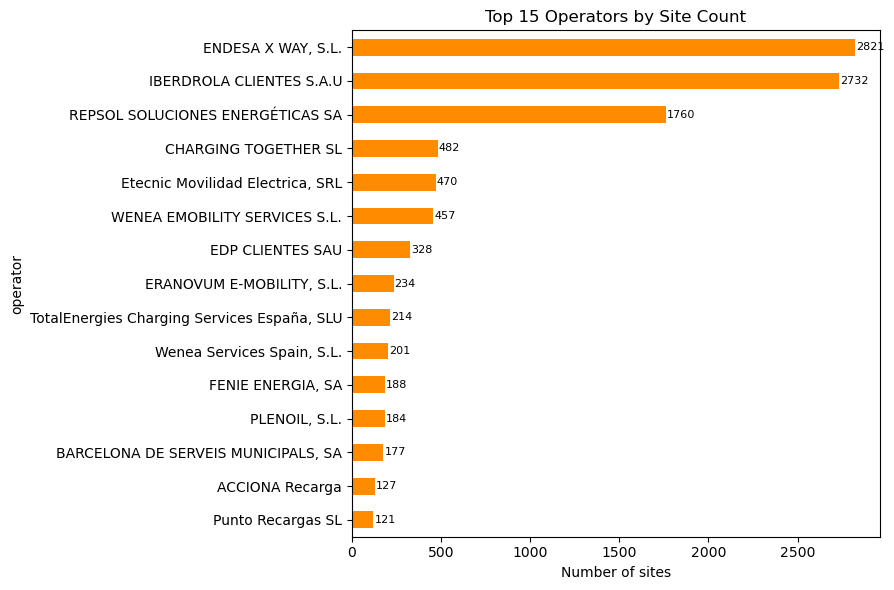

In [60]:
# Market structure — top 15 operators by site count and their combined market share
fig, ax = plt.subplots(figsize=(9, 6))
top_ops = gdf_all['operator'].value_counts().head(15)
top_ops[::-1].plot(kind='barh', ax=ax, color='darkorange')
ax.set_title('Top 15 Operators by Site Count')
ax.set_xlabel('Number of sites')
top15_share = top_ops.sum() / len(gdf_all) * 100
for i, v in enumerate(top_ops[::-1]):
    ax.text(v + 5, i, str(v), va='center', fontsize=8)
print(f'Top 15 operators control {top15_share:.1f}% of all sites')
plt.tight_layout()
plt.show()

Sites with ≤2 connectors : 8,212  (68.0%)
Sites with ≥6 connectors : 1,336  (11.1%)


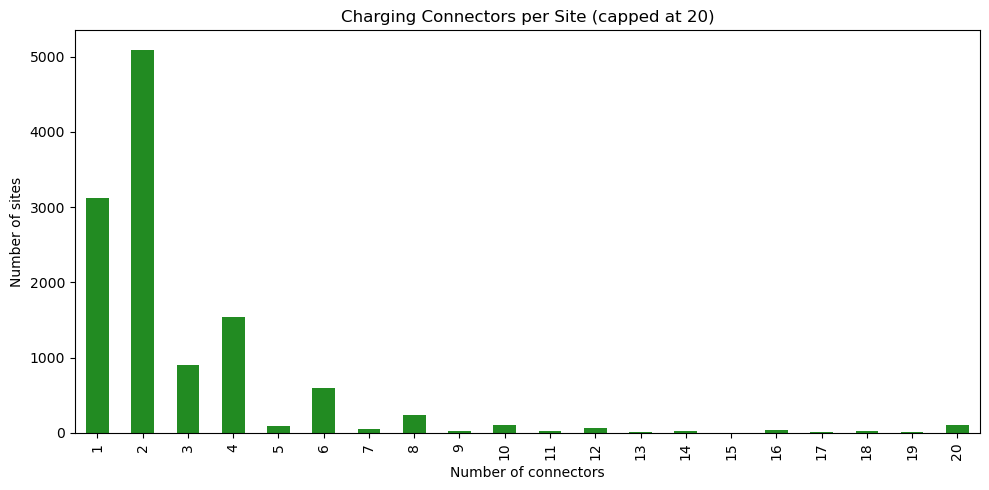

In [62]:
# Connector density distribution — reveals whether sites are single-point or multi-point hubs
fig, ax = plt.subplots(figsize=(10, 5))
gdf_all['n_refill_points'].clip(upper=20).value_counts().sort_index().plot(
    kind='bar', ax=ax, color='forestgreen')
ax.set_title('Charging Connectors per Site (capped at 20)')
ax.set_xlabel('Number of connectors')
ax.set_ylabel('Number of sites')
single = (gdf_all['n_refill_points'] <= 2).sum()
print(f'Sites with ≤2 connectors : {single:,}  ({single/len(gdf_all)*100:.1f}%)')
print(f'Sites with ≥6 connectors : {(gdf_all["n_refill_points"] >= 6).sum():,}  ({(gdf_all["n_refill_points"] >= 6).mean()*100:.1f}%)')
plt.tight_layout()
plt.show()

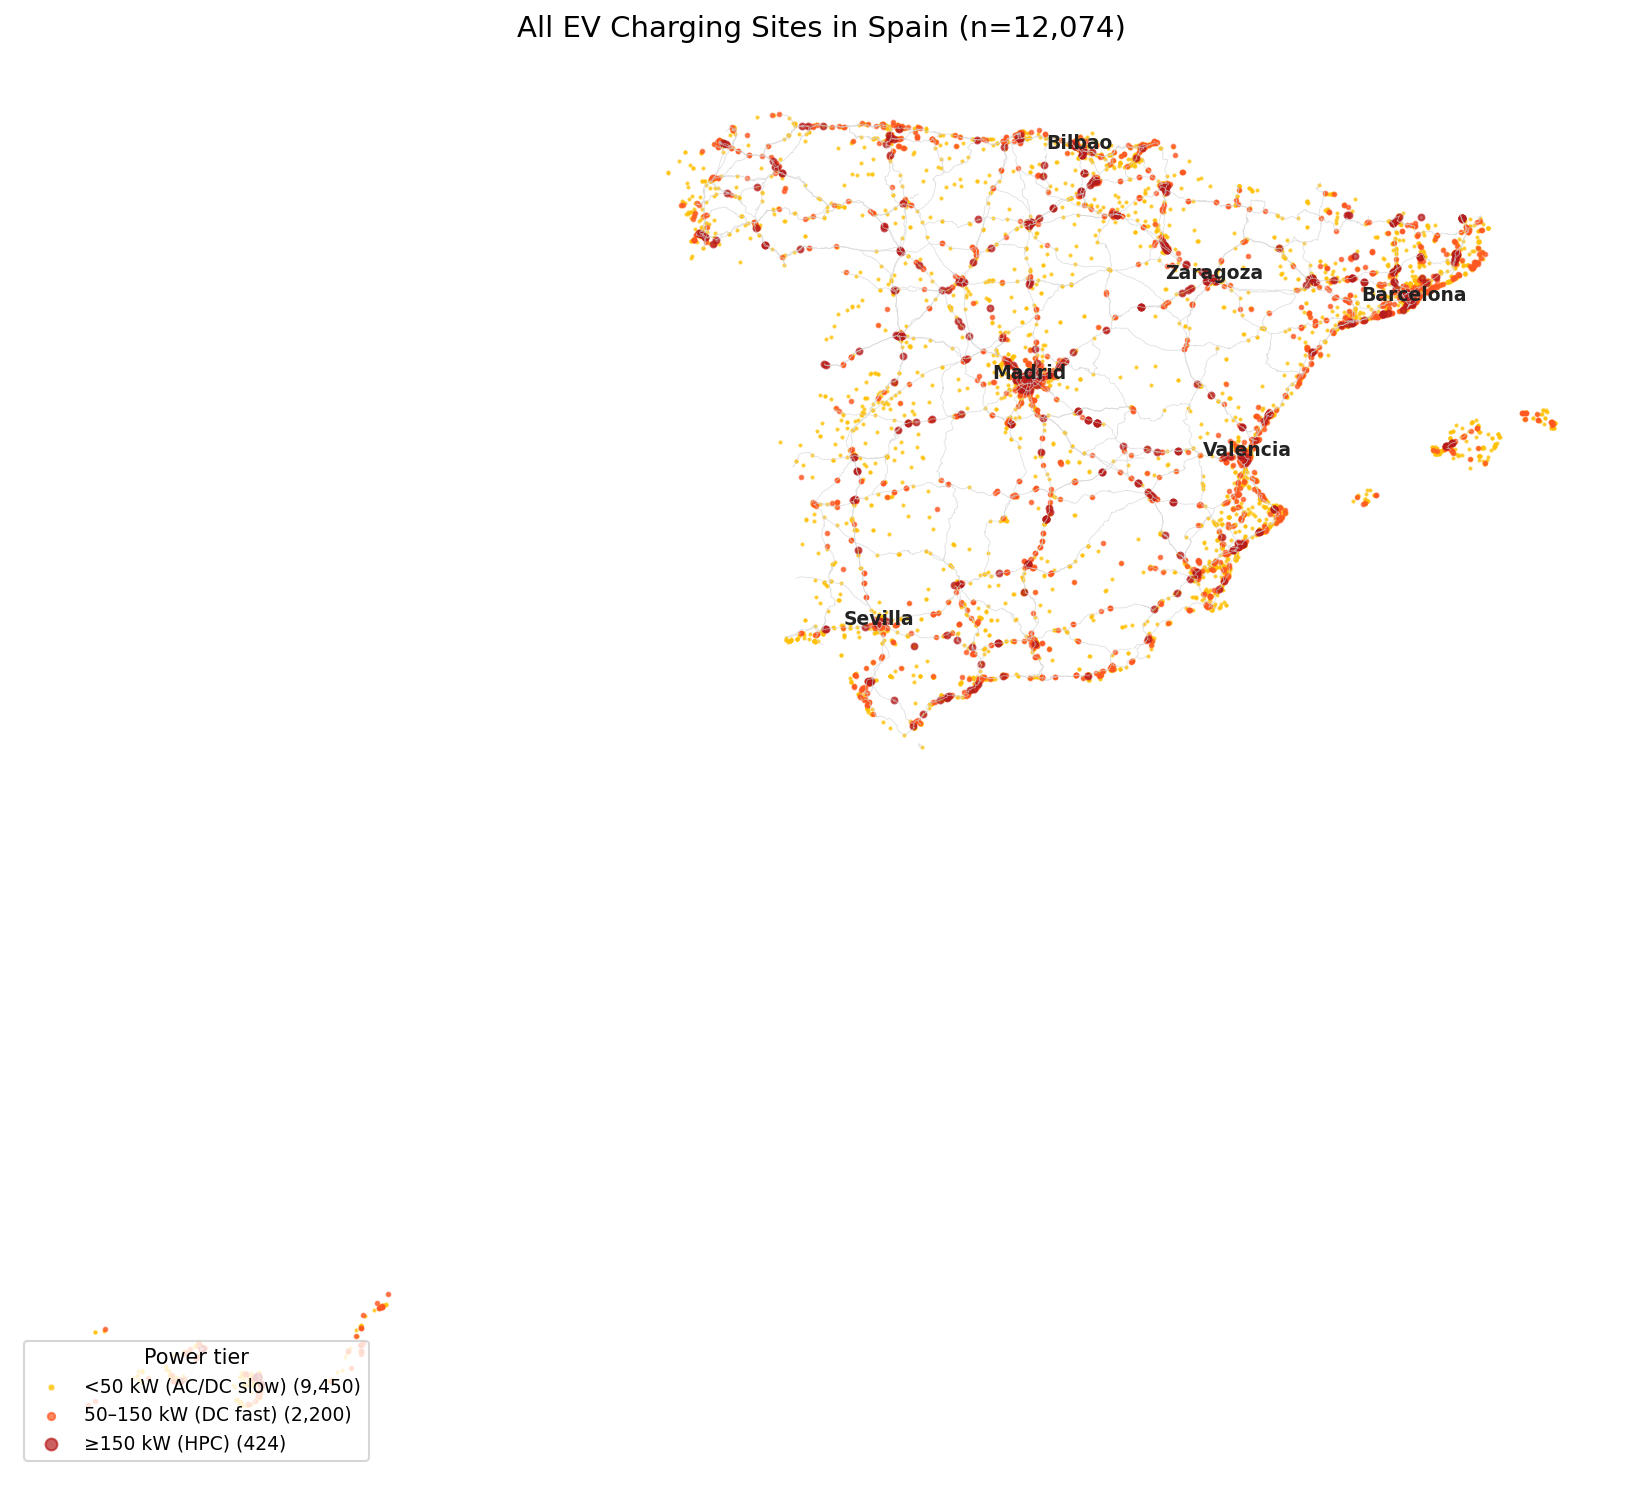

In [65]:
# Geographic spread — overlay on road network for spatial context
fig, ax = plt.subplots(figsize=(12, 10), dpi=150)

# Road network as base reference
roads.plot(ax=ax, color='lightgrey', linewidth=0.4, alpha=0.7)

# Charging sites colored and sized by power tier
power_bins   = [0, 50, 150, float('inf')]
power_labels = ['<50 kW (AC/DC slow)', '50–150 kW (DC fast)', '≥150 kW (HPC)']
power_colors = ['#FFC107', '#FF5722', '#B71C1C']
marker_sizes = [1, 3, 8]

gdf_all['power_cat'] = pd.cut(gdf_all['max_power_kw'], bins=power_bins, labels=power_labels)

for label, color, size in zip(power_labels, power_colors, marker_sizes):
    subset = gdf_all[gdf_all['power_cat'] == label]
    subset.plot(ax=ax, markersize=size, color=color, alpha=0.7, label=f'{label} ({len(subset):,})')

# City labels
cities = {'Madrid': (-3.70, 40.42), 'Barcelona': (2.15, 41.38),
          'Valencia': (-0.38, 39.47), 'Sevilla': (-5.99, 37.39),
          'Bilbao': (-2.93, 43.26), 'Zaragoza': (-0.88, 41.65)}
for city, (lon, lat) in cities.items():
    ax.annotate(city, xy=(lon, lat), fontsize=9, color='#222222',
                ha='center', fontweight='bold')

ax.legend(fontsize=9, loc='lower left', title='Power tier', markerscale=2)
ax.set_title(f'All EV Charging Sites in Spain (n={len(gdf_all):,})', fontsize=14)
ax.axis('off')
plt.tight_layout()
plt.show()


**EV Charging Infrastructure Baseline**

Spain has 12,074 registered public EV charging sites nationally, but the power distribution reveals a significant quality gap. The dominant bands are 7.4–22 kW AC (36.1%, 4,355 sites) and 22–50 kW AC fast (29.0%, 3,500 sites), together accounting for 65% of all sites. These are suitable for destination charging but not for interurban travel where drivers need to charge in under 30 minutes. Only 424 sites (3.5%) reach true HPC level (≥150 kW), the minimum threshold for a meaningful interurban charging stop.

The market is highly concentrated. The top three operators — Endesa X Way (2,821), Iberdrola Clientes (2,732), and Repsol (1,760) — together control 61% of all sites. This oligopolistic structure means that infrastructure expansion decisions by a small number of players have outsized national impact.

Site density is low: 67% of sites have only 1–2 connectors, limiting throughput per location. A genuine HPC hub typically requires 6+ high-power connectors to serve simultaneous demand; very few existing sites meet this standard.

Geographically, charging infrastructure closely mirrors population density, with dense clusters around Madrid, Barcelona, and the Mediterranean coast, and sparse coverage in the interior plateau and the northwest. HPC sites (dark red) are almost exclusively confined to major corridors and urban centres, leaving large stretches of the interurban network without rapid charging options.

---
## 3. Interurban Filter & Road Coverage Gap (M2)

In [68]:
# Load interurban subset and compute power tier breakdown
df_interurban = pd.read_csv(M2_INTERURBAN)
gdf_interurban = gpd.GeoDataFrame(
    df_interurban,
    geometry=gpd.points_from_xy(df_interurban['longitude'], df_interurban['latitude']),
    crs='EPSG:4326'
)
n_interurban = len(gdf_interurban)
n_total      = len(gdf_all)

power_bins   = [0, 50, 150, float('inf')]
power_labels = ['<50 kW (AC/DC slow)', '50–150 kW (DC fast)', '≥150 kW (HPC)']
power_colors = ['gold', 'darkorange', 'crimson']
gdf_interurban['power_cat'] = pd.cut(
    gdf_interurban['max_power_kw'], bins=power_bins, labels=power_labels)
tier_counts = gdf_interurban['power_cat'].value_counts().reindex(power_labels)
n_stations  = n_interurban

print(f'Total national sites : {n_total:,}')
print(f'Interurban sites     : {n_interurban:,}  ({n_interurban/n_total*100:.1f}%)')
print(f'Unique roads covered : {gdf_interurban["Carretera"].nunique():,}')
print()
print('Power tier breakdown (interurban):')
for label, count in tier_counts.items():
    print(f'  {label:<25s}: {count:,} ({count/n_stations*100:.0f}%)')


Total national sites : 12,074
Interurban sites     : 3,679  (30.5%)
Unique roads covered : 281

Power tier breakdown (interurban):
  <50 kW (AC/DC slow)      : 2,510 (68%)
  50–150 kW (DC fast)      : 873 (24%)
  ≥150 kW (HPC)            : 296 (8%)


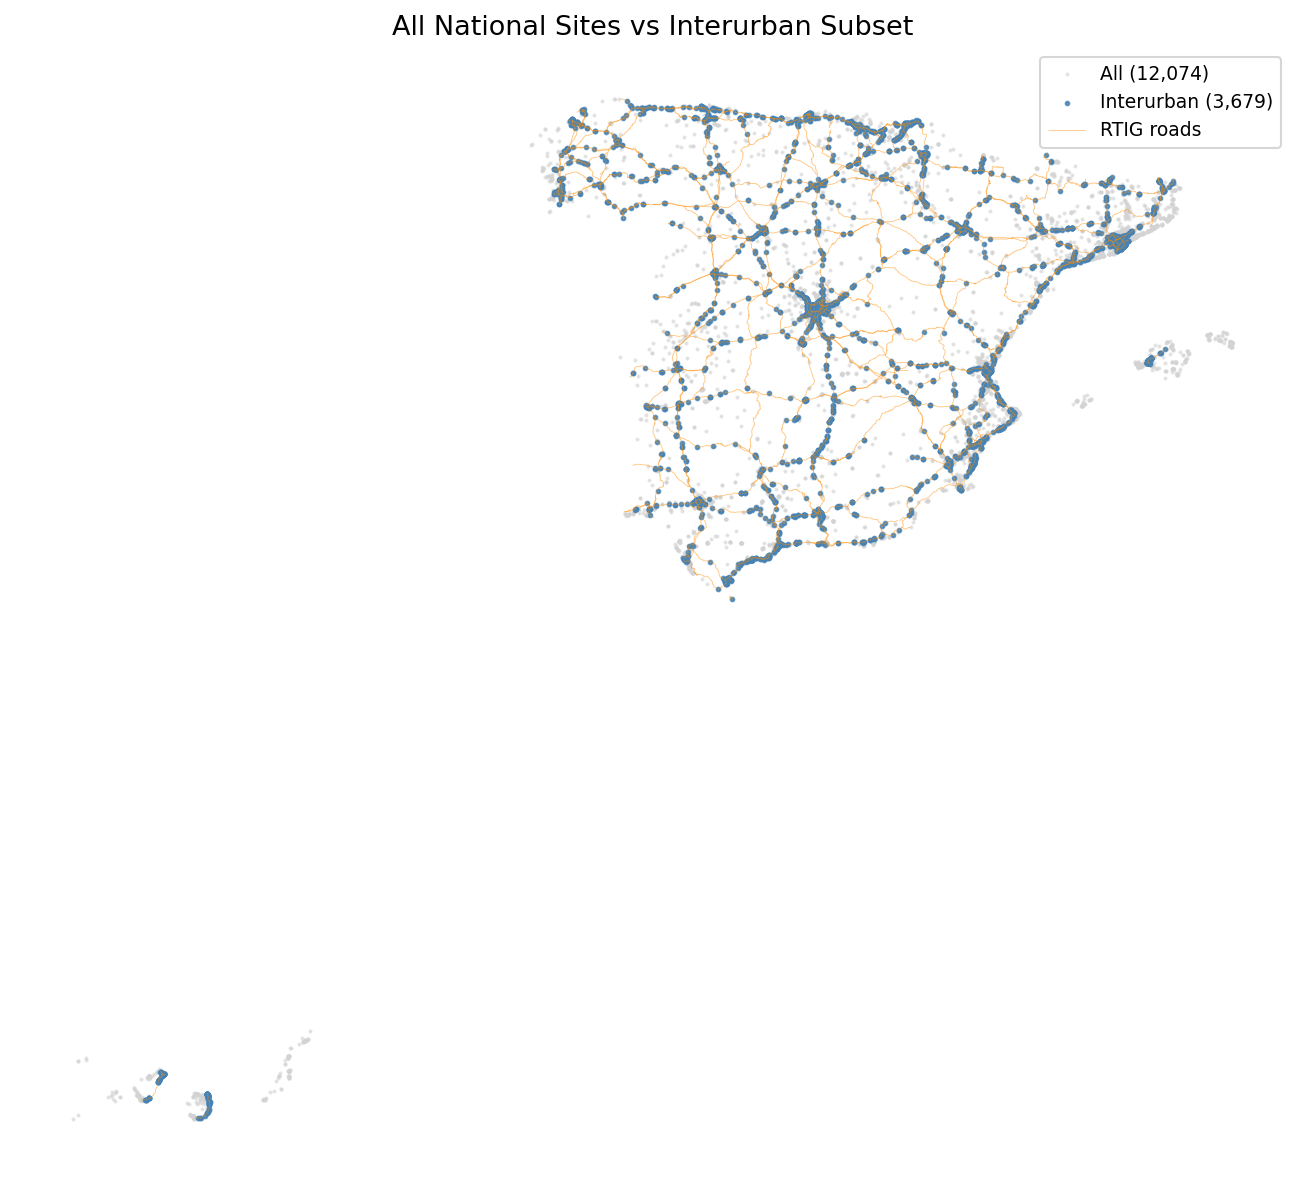

In [69]:
# Spatial filter result — compare all national sites vs interurban subset
fig, ax = plt.subplots(figsize=(10, 8), dpi=150)
gdf_all.plot(ax=ax, markersize=1, color='lightgrey', alpha=0.5, label=f'All ({n_total:,})')
gdf_interurban.plot(ax=ax, markersize=3, color='steelblue', alpha=0.8, label=f'Interurban ({n_interurban:,})')
roads.plot(ax=ax, linewidth=0.4, color='darkorange', alpha=0.5, label='RTIG roads')
ax.legend(fontsize=9)
ax.set_title('All National Sites vs Interurban Subset', fontsize=13)
ax.axis('off')
plt.tight_layout()
plt.show()

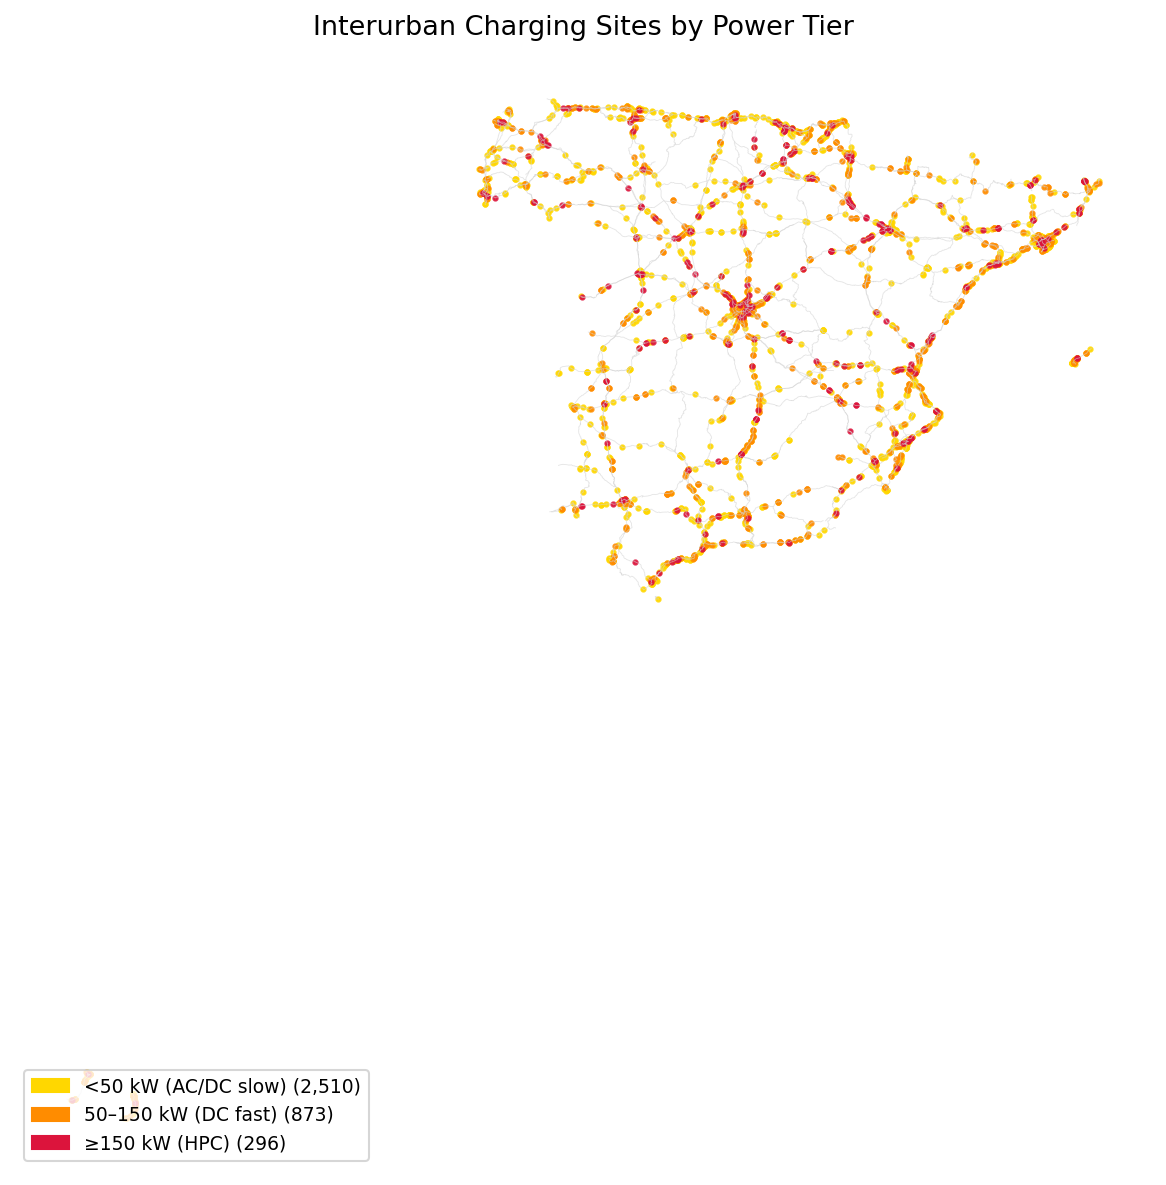

In [70]:
# Power tier distribution of interurban stations along the RTIG network
fig, ax = plt.subplots(figsize=(10, 8), dpi=150)
roads.plot(ax=ax, linewidth=0.4, color='lightgrey', alpha=0.6)
handles = []
for label, color in zip(power_labels, power_colors):
    subset = gdf_interurban[gdf_interurban['power_cat'] == label]
    subset.plot(ax=ax, markersize=4, color=color, alpha=0.85)
    handles.append(mpatches.Patch(color=color, label=f'{label} ({len(subset):,})'))
ax.legend(handles=handles, fontsize=9, loc='lower left')
ax.set_title('Interurban Charging Sites by Power Tier', fontsize=13)
ax.axis('off')
plt.tight_layout()
plt.show()

In [71]:
# Load road coverage data and compute gap statistics
coverage = pd.read_csv(M2_COVERAGE)
GAP_KM = 50
total_km_net = coverage['length_m'].sum() / 1000
gap_km_val   = coverage[coverage['has_gap']]['length_m'].sum() / 1000
covered_pct  = (1 - gap_km_val / total_km_net) * 100

print(f'Total network  : {total_km_net:,.0f} km')
print(f'Covered (≤{GAP_KM}km): {total_km_net-gap_km_val:,.0f} km  ({covered_pct:.1f}%)')
print(f'Gap (>{GAP_KM}km)    : {gap_km_val:,.0f} km  ({100-covered_pct:.1f}%)')
print()
print('Top roads with largest gap:')
top_gaps = (coverage.groupby('Carretera')['nearest_station_m']
            .max().sort_values(ascending=False).head(10).div(1000).round(1))
for road, km_gap in top_gaps.items():
    print(f'  {road:<12s}  {km_gap:.1f} km')

Total network  : 29,050 km
Covered (≤50km): 28,920 km  (99.6%)
Gap (>50km)    : 130 km  (0.4%)

Top roads with largest gap:
  N-502         51.9 km
  N-502A        50.7 km
  N-322         48.5 km
  N-211         45.6 km
  N-111         37.8 km
  N-430         35.1 km
  N-232A        33.1 km
  N-111A        31.6 km
  N-430A        31.4 km
  N-401         30.2 km


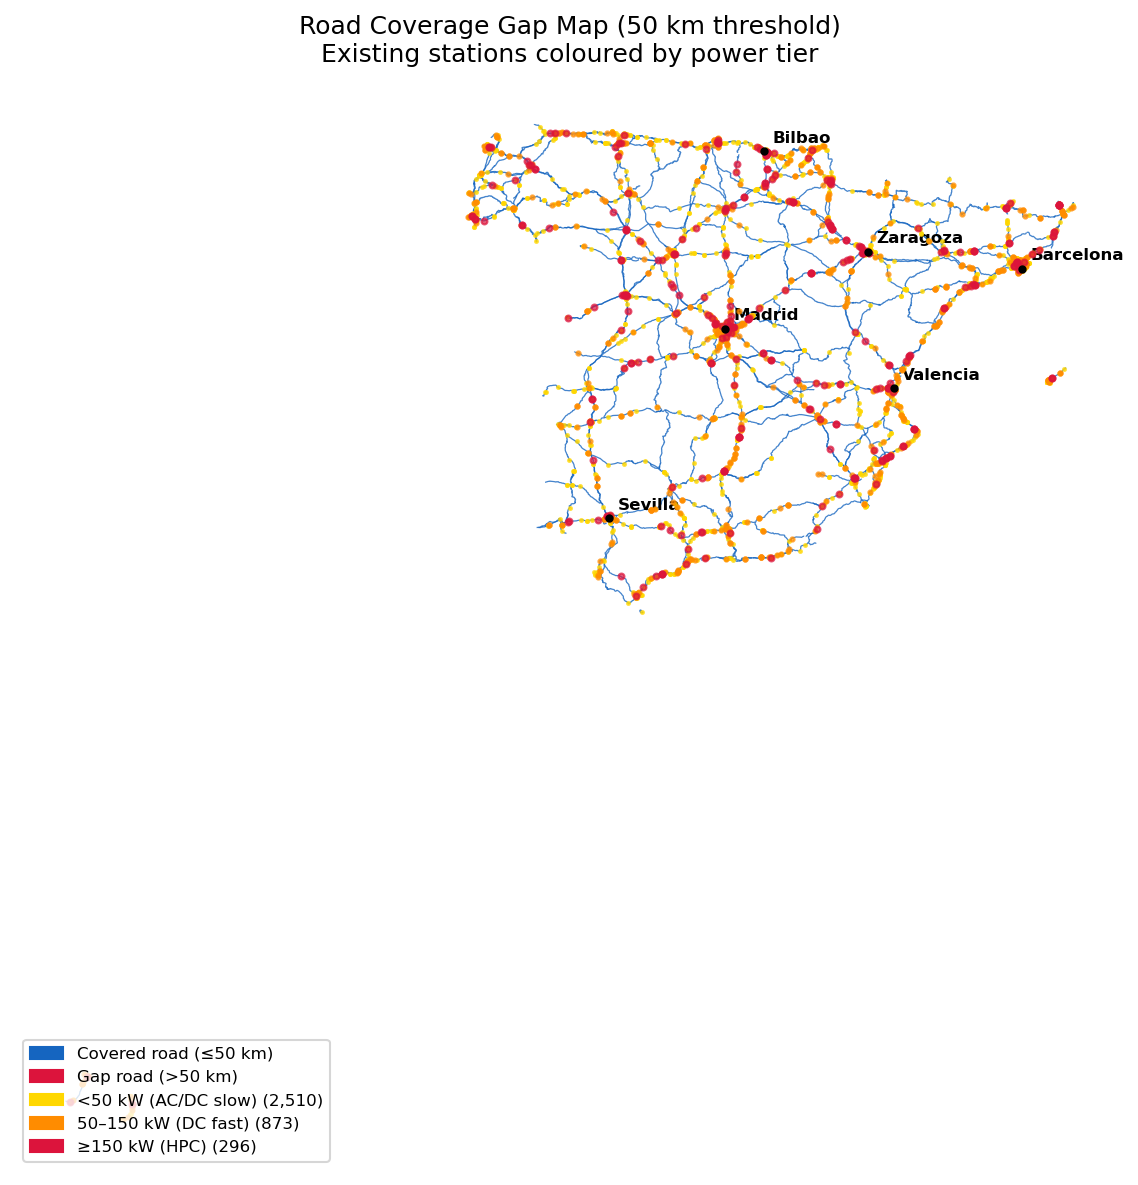

In [74]:
# Map covered vs gap road segments against existing station locations
fig, ax = plt.subplots(figsize=(10, 8), dpi=150)

covered_roads.plot(ax=ax, color='#1565C0', linewidth=0.6, alpha=0.8,
                   label=f'Covered (≤{GAP_KM} km)')
if len(gap_roads) > 0:
    gap_roads.plot(ax=ax, color='crimson', linewidth=2.5,
                   label=f'Gap (>{GAP_KM} km)')

# HPC stations larger, slow stations smaller
for label, color, size in zip(power_labels, power_colors, [2, 4, 8]):
    subset = gdf_interurban[gdf_interurban['power_cat'] == label]
    subset.plot(ax=ax, markersize=size, color=color, alpha=0.7, zorder=5)

# Station legend separately
station_handles = [mpatches.Patch(color=c, label=f'{l} ({tier_counts[l]:,})')
                   for l, c in zip(power_labels, power_colors)]
road_handles = [
    mpatches.Patch(color='#1565C0', label=f'Covered road (≤{GAP_KM} km)'),
    mpatches.Patch(color='crimson', label=f'Gap road (>{GAP_KM} km)'),
]
ax.legend(handles=road_handles + station_handles, fontsize=8, loc='lower left')

# City labels
cities = {'Madrid':    (-3.70, 40.42), 'Barcelona': (2.15,  41.38),
          'Valencia':  (-0.38, 39.47), 'Sevilla':   (-5.99, 37.39),
          'Bilbao':    (-2.93, 43.26), 'Zaragoza':  (-0.88, 41.65)}
for city, (lon, lat) in cities.items():
    ax.plot(lon, lat, 'o', color='black', markersize=3, zorder=6)
    ax.annotate(city, xy=(lon, lat), xytext=(4, 4),
                textcoords='offset points', fontsize=8, fontweight='bold')

ax.set_title(f'Road Coverage Gap Map ({GAP_KM} km threshold)\n'
             f'Existing stations coloured by power tier', fontsize=12)
ax.axis('off')
plt.tight_layout()
plt.show()


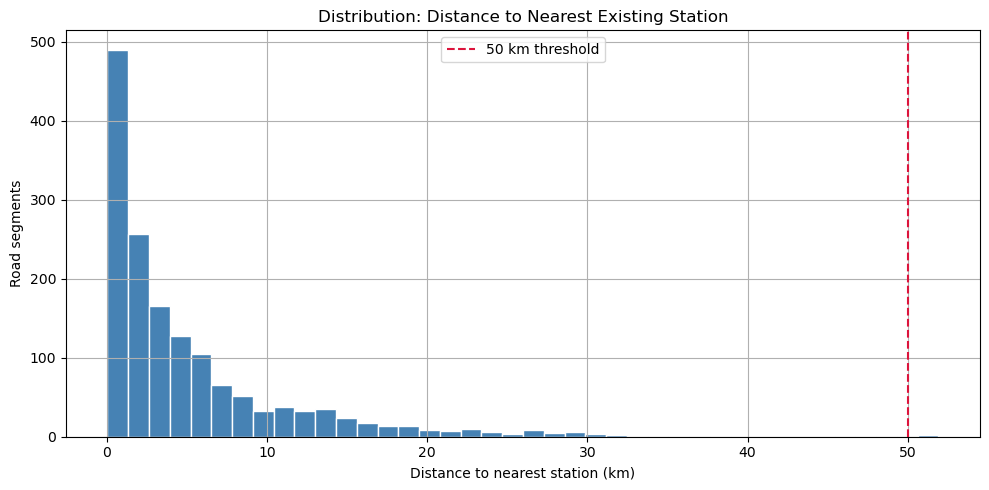

In [73]:
# Distribution of distances from each road segment to its nearest existing station
fig, ax = plt.subplots(figsize=(10, 5))
coverage['nearest_km'] = coverage['nearest_station_m'] / 1000
coverage['nearest_km'].clip(upper=200).hist(bins=40, ax=ax, color='steelblue', edgecolor='white')
ax.axvline(GAP_KM, color='crimson', linestyle='--', linewidth=1.5, label=f'{GAP_KM} km threshold')
ax.set_xlabel('Distance to nearest station (km)')
ax.set_ylabel('Road segments')
ax.set_title('Distribution: Distance to Nearest Existing Station')
ax.legend()
plt.tight_layout()
plt.show()

**Interurban Filter & Road Coverage Gap**

Of Spain's 12,074 national charging sites, only 3,679 (30.5%) fall within 500 m of the eligible RTIG road network, covering 281 unique roads. The majority of existing infrastructure is urban-focused and irrelevant to interurban travel needs.

The power quality picture among interurban sites is better than the national average but still inadequate. 68% of interurban stations are below 50 kW, suitable only for slow top-up stops rather than genuine rapid charging. Only 296 sites (8%) reach HPC level (≥150 kW), and these are concentrated on the busiest corridors around Madrid, Barcelona, and the Mediterranean coast, as visible in the power tier map.

Road coverage at the 50 km threshold is 99.6%, meaning the geographic gap problem is nearly solved. The distance distribution histogram confirms this: the vast majority of road segments have a nearest station within 10 km. The few remaining gap roads are all carreteras nacionales (N-502, N-322, N-211), not motorways, and their maximum gap distances of 50–52 km are only marginally above the threshold.

The core implication is that Spain's interurban charging problem is a quality problem, not a coverage problem. The network needs HPC upgrades at existing sites far more urgently than new geographic coverage. The 2,510 slow sites on interurban roads represent the primary upgrade opportunity.

---
## 4. BEV Fleet Projection 2027 (M3)

**Model: Logistic market penetration curve** fitted on Spain's annual BEV registration data.

Why not SARIMA? The SARIMA model (tested on the DGT parquets) predicted *declining* new BEV sales post-2024 due to noise and seasonal artefacts in the monthly data. A logistic penetration model is more appropriate for EV adoption, which follows an S-curve driven by falling costs and infrastructure build-out.

In [42]:
from scipy.optimize import curve_fit

parquet_files = sorted(glob.glob(f'{M3_PARQUET}/*.parquet'))

if parquet_files:
    dfs = [pd.read_parquet(f) for f in parquet_files]
    df_raw = pd.concat(dfs, ignore_index=True)
    df_raw['COD_TIPO']           = df_raw['COD_TIPO'].astype(str).str.strip()
    df_raw['CLAVE_TRAMITE']      = df_raw['CLAVE_TRAMITE'].astype(str).str.strip()
    df_raw['COD_PROPULSION_ITV'] = df_raw['COD_PROPULSION_ITV'].astype(str).str.strip()
    df_cars = df_raw[
        (df_raw['COD_TIPO'] == '40') &
        (df_raw['CLAVE_TRAMITE'].isin(['1','5','B']))
    ].copy()
    df_cars['year'] = df_cars['FEC_MATRICULA'].astype(str).str[4:8].astype(int, errors='ignore')
    df_cars = df_cars[df_cars['year'].between(2015, 2023)]
    annual = pd.DataFrame({
        'total': df_cars.groupby('year').size(),
        'bev':   df_cars[df_cars['COD_PROPULSION_ITV']=='6'].groupby('year').size(),
    }).fillna(0).astype(int)
    annual['penetration'] = annual['bev'] / annual['total']
    DATA_SOURCE = 'DGT parquets'
else:
    # Reliable published values (ANFAC / DGT official stats)
    annual = pd.DataFrame({
        'total': {2019:960000, 2020:851000, 2021:860000, 2022:900000, 2023:950000},
        'bev':   {2019:2516,   2020:3625,   2021:9601,   2022:15882,  2023:27928},
    })
    annual['penetration'] = annual['bev'] / annual['total']
    DATA_SOURCE = 'hardcoded (no parquets)'

print(f'Source: {DATA_SOURCE}')
print()
print(f'{"Year":>6}  {"Total cars":>12}  {"BEV":>8}  {"Penetration":>12}')
for yr, row in annual.iterrows():
    print(f'{yr:>6}  {row["total"]:>12,}  {row["bev"]:>8,}  {row["penetration"]:>11.2%}')

Source: hardcoded (no parquets)

  Year    Total cars       BEV   Penetration
  2019     960,000.0   2,516.0        0.26%
  2020     851,000.0   3,625.0        0.43%
  2021     860,000.0   9,601.0        1.12%
  2022     900,000.0  15,882.0        1.76%
  2023     950,000.0  27,928.0        2.94%


**Why a Logistic Model?**

EV adoption follows a classic S-curve: slow initial uptake during the early-adopter phase, rapid acceleration as costs fall and infrastructure matures, then gradual saturation as the market approaches maximum penetration. A logistic function directly models this dynamic, with three interpretable parameters: L (long-run saturation level), k (growth steepness), and t₀ (inflection year of fastest adoption).

The alternative（ a SARIMA time series model applied to monthly registration data） was tested and rejected. The DGT parquet data contains significant noise from COVID-related demand collapse in 2020 and irregular registration patterns in earlier years. SARIMA captured these fluctuations as seasonal structure, producing a forecast of declining annual BEV sales from 2024 onwards, which is inconsistent with observed market dynamics and policy direction (Spain's PNIEC 2021–2030 targets 5 million EVs by 2030).

The logistic model is fitted on 2019–2023 data only, the period in which policy support (MOVES III grants, charging infrastructure subsidies) and falling battery costs drove the structural acceleration in adoption. Pre-2019 data reflects a different, pre-acceleration regime and is excluded from the fit.

In [81]:
# Fit logistic curve to BEV market penetration rate (2019-2023)
def logistic(t, L, k, t0):
    return L / (1 + np.exp(-k * (t - t0)))

fit_data  = annual[annual.index >= 2019]
years_fit = fit_data.index.astype(float).values
pens_fit  = fit_data['penetration'].values

popt, _ = curve_fit(
    logistic, years_fit, pens_fit,
    p0=[0.30, 0.5, 2027],
    bounds=([0.10, 0.05, 2023], [1.0, 5.0, 2035]),
    maxfev=10000
)
L, k, t0 = popt
print(f'Logistic params:  L={L:.3f}  k={k:.3f}  t0={t0:.1f}')
print(f'Implied max penetration: {L*100:.1f}%')
print(f'Inflection year:         {t0:.1f}')


Logistic params:  L=0.100  k=0.665  t0=2024.3
Implied max penetration: 10.0%
Inflection year:         2024.3


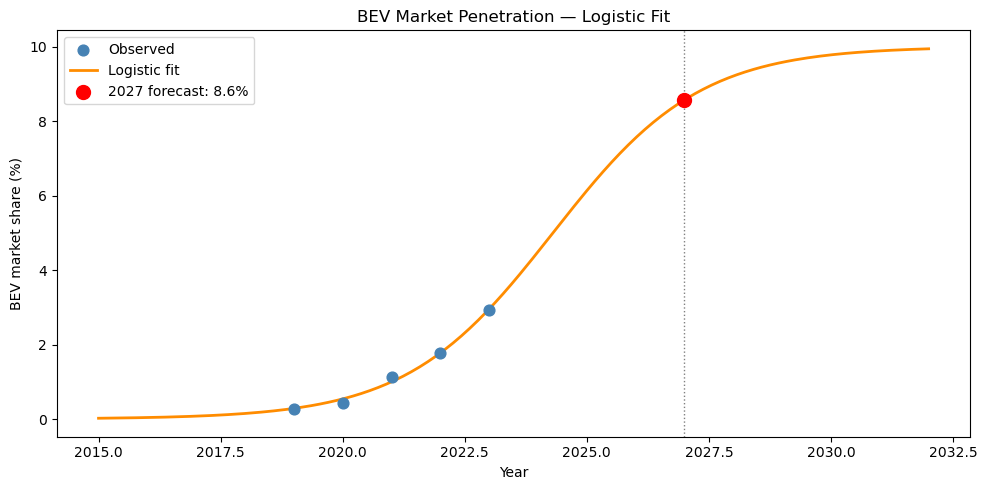

In [75]:
# Logistic fit vs observed penetration rate, with 2027 forecast point
t_smooth = np.linspace(2015, 2032, 200)

fig, ax = plt.subplots(figsize=(10, 5))
ax.scatter(annual.index, annual['penetration']*100,
           color='steelblue', zorder=5, s=60, label='Observed')
ax.plot(t_smooth, logistic(t_smooth, *popt)*100,
        color='darkorange', lw=2, label='Logistic fit')
ax.axvline(2027, color='grey', ls=':', lw=1)
ax.scatter([2027], [logistic(2027, *popt)*100],
           color='red', s=100, zorder=6,
           label=f'2027 forecast: {logistic(2027,*popt)*100:.1f}%')
ax.set_xlabel('Year')
ax.set_ylabel('BEV market share (%)')
ax.set_title('BEV Market Penetration — Logistic Fit')
ax.legend()
plt.tight_layout()
plt.show()

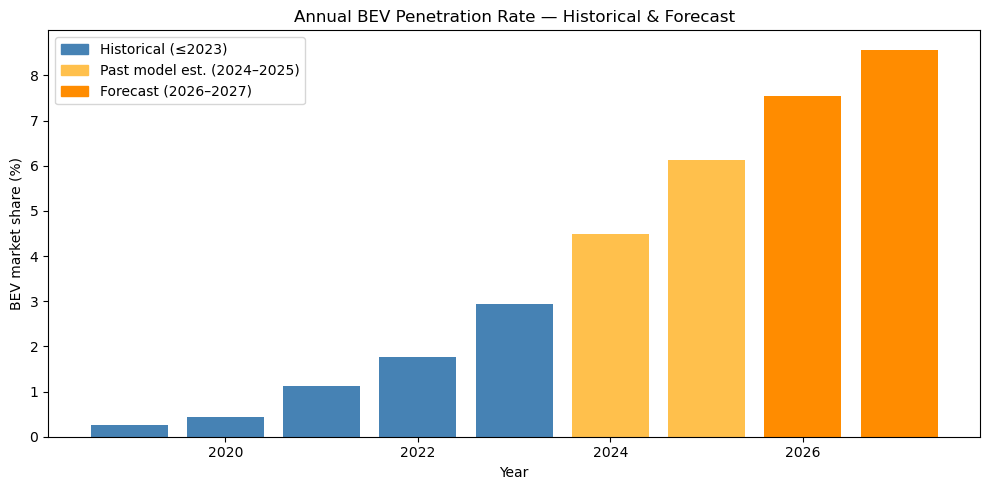

In [82]:
# Historical vs projected annual BEV market share
# Blue = confirmed historical (≤2023); Amber = past model est. (2024–2025); Orange = forecast (2026–2027)
HIST_COLOR   = 'steelblue'
PAST_COLOR   = '#FFC04C'
FORE_COLOR   = 'darkorange'
CURRENT_YEAR = 2026

proj_years = range(2024, 2028)
proj_pens  = {y: logistic(float(y), *popt) for y in proj_years}
all_pens   = pd.concat([annual['penetration'], pd.Series(proj_pens)])
colors_pen = [HIST_COLOR if y <= 2023 else (PAST_COLOR if y < CURRENT_YEAR else FORE_COLOR)
              for y in all_pens.index]

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(all_pens.index, all_pens.values * 100, color=colors_pen)
ax.set_xlabel('Year')
ax.set_ylabel('BEV market share (%)')
ax.set_title('Annual BEV Penetration Rate — Historical & Forecast')
ax.legend(handles=[
    mpatches.Patch(color=HIST_COLOR, label='Historical (≤2023)'),
    mpatches.Patch(color=PAST_COLOR, label='Past model est. (2024–2025)'),
    mpatches.Patch(color=FORE_COLOR, label='Forecast (2026–2027)')])
plt.tight_layout()
plt.show()


In [77]:
# Project annual new BEV registrations 2024-2027 using logistic penetration + 2% market growth
base_market = int(annual['total'].iloc[-1])
proj_bev = {
    y: int(base_market * (1.02 ** (y - 2023)) * logistic(float(y), *popt))
    for y in range(2024, 2028)
}
fleet_baseline_2023     = int(annual['bev'].sum())
projected_2024_2027     = sum(proj_bev.values())
total_ev_projected_2027 = fleet_baseline_2023 + projected_2024_2027

print(f'Fleet baseline (all BEV 2015–2023):   {fleet_baseline_2023:>10,}')
print(f'Projected new registrations 2024–2027: {projected_2024_2027:>8,}')
print(f'total_ev_projected_2027:               {total_ev_projected_2027:>10,}')
print()
for y, n in proj_bev.items():
    print(f'  {y}: {n:,} new BEVs  ({logistic(float(y),*popt)*100:.1f}% market share)')

Fleet baseline (all BEV 2015–2023):       59,552
Projected new registrations 2024–2027:  268,331
total_ev_projected_2027:                  327,883

  2024: 43,510 new BEVs  (4.5% market share)
  2025: 60,595 new BEVs  (6.1% market share)
  2026: 76,108 new BEVs  (7.5% market share)
  2027: 88,118 new BEVs  (8.6% market share)


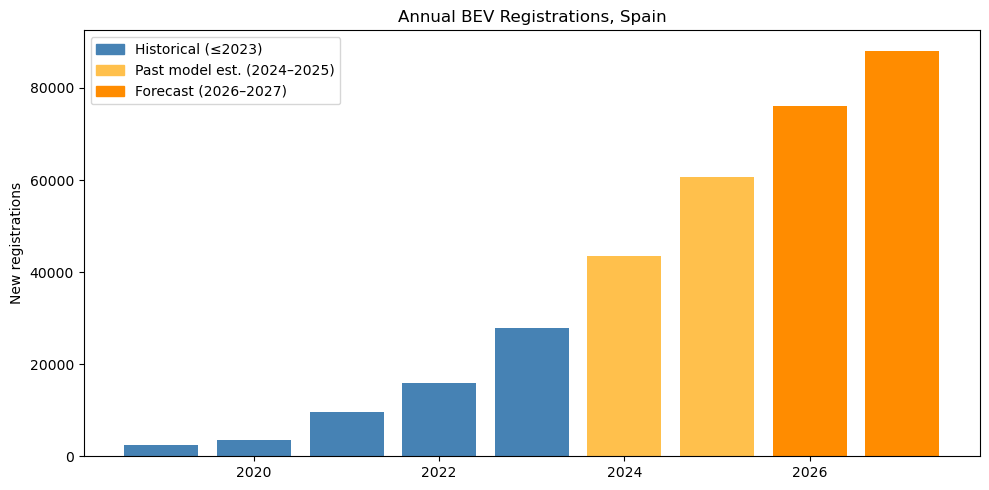

In [83]:
# Annual BEV registrations: historical / past model est. / forecast
# Blue = ≤2023 confirmed; Amber = 2024–2025 past est.; Orange = 2026–2027 forecast
hist_bev   = annual['bev']
proj_s     = pd.Series(proj_bev)
all_annual = pd.concat([hist_bev, proj_s])
bar_colors = [HIST_COLOR if y <= 2023 else (PAST_COLOR if y < CURRENT_YEAR else FORE_COLOR)
              for y in all_annual.index]

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(all_annual.index, all_annual.values, color=bar_colors)
ax.set_title('Annual BEV Registrations, Spain')
ax.set_ylabel('New registrations')
ax.legend(handles=[
    mpatches.Patch(color=HIST_COLOR, label='Historical (≤2023)'),
    mpatches.Patch(color=PAST_COLOR, label='Past model est. (2024–2025)'),
    mpatches.Patch(color=FORE_COLOR, label='Forecast (2026–2027)')])
plt.tight_layout()
plt.show()


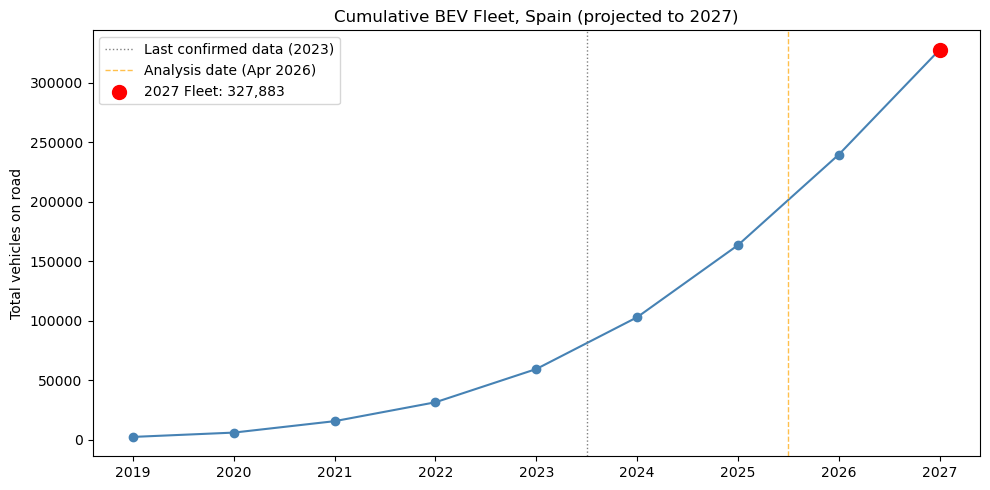

In [84]:
# Cumulative BEV fleet growth to 2027
cumulative = all_annual.cumsum()

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(cumulative.index, cumulative.values, marker='o', color='steelblue')
ax.axvline(x=2023.5, color='grey',     ls=':',  lw=1, label='Last confirmed data (2023)')
ax.axvline(x=2025.5, color=PAST_COLOR, ls='--', lw=1, label='Analysis date (Apr 2026)')
ax.scatter([2027], [total_ev_projected_2027], color='red', s=100, zorder=5,
           label=f'2027 Fleet: {total_ev_projected_2027:,}')
ax.set_title('Cumulative BEV Fleet, Spain (projected to 2027)')
ax.set_ylabel('Total vehicles on road')
ax.legend()
plt.tight_layout()
plt.show()


In [85]:
# Save projection output for use in downstream analysis
from datetime import date
os.makedirs(f'{BASE}/Data/processed', exist_ok=True)
with open(M3_JSON, 'w') as f:
    json.dump({
        'total_ev_projected_2027': total_ev_projected_2027,
        'fleet_baseline_2023': fleet_baseline_2023,
        'projected_registrations_2024_2027': projected_2024_2027,
        'logistic_params': {'L': round(float(L),4), 'k': round(float(k),4), 't0': round(float(t0),2)},
        'annual_forecast': {str(y): v for y, v in proj_bev.items()},
        'model': 'Logistic penetration curve fitted on 2019-2023',
        'generated_at': str(date.today()),
    }, f, indent=2)
print(f'Saved → {M3_JSON}')


Saved → /Users/isabelwu/Desktop/Project/IberdrolaDatathon/Datathon/Data/processed/m3_ev_projection.json


**BEV Fleet Projection (Logistic Model)**

Spain's BEV market share grew from 0.3% in 2019 to 2.9% in 2023, confirming the country is in the early exponential phase of EV adoption. The logistic model, fitted on this five-year window, projects that share will reach 8.6% by 2027 as Spain approaches the inflection point of the S-curve around 2027–2028, the year at which annual adoption growth begins to plateau toward the modelled ceiling of ~10%.

In absolute terms, annual new BEV registrations are forecast to grow from ~28,000 in 2023 to ~88,000 by 2027, nearly tripling over four years. This trajectory reflects a combination of rising penetration rates and a modest assumed 2% annual growth in the total car market.

Cumulatively, Spain's BEV fleet is projected to reach ~328,000 vehicles by end-2027, comprising 59,552 vehicles confirmed on the road through 2023 plus an estimated 268,331 new registrations over 2024–2027. Against the 3,679 interurban charging stations identified in M2, this implies a ratio of roughly 89 EVs per station, far exceeding the comfortable utilisation benchmark of 20–50 EVs per station and establishing the quantitative basis for the supply–demand gap analysis in Section 5.

---
## 5. Cross-Dataset Synthesis — 2027 Supply–Demand Gap

In [87]:
# Compute 2027 supply-demand gap under two utilisation benchmarks
benchmark_low  = 20    # EVs per station at comfortable utilisation
benchmark_high = 50    # EVs per station at high utilisation
ev_per_station = total_ev_projected_2027 / n_stations

stations_needed_low  = int(total_ev_projected_2027 / benchmark_low)
stations_needed_high = int(total_ev_projected_2027 / benchmark_high)
gap_low  = max(0, stations_needed_low  - n_stations)
gap_high = max(0, stations_needed_high - n_stations)

print(f'Existing interurban stations : {n_stations:,}')
print(f'Projected EVs (2027)         : {total_ev_projected_2027:,}')
print(f'EVs per existing station     : {ev_per_station:,.0f}')
print()
print(f'Benchmark (20 EVs/station)   : {stations_needed_low:,} stations needed  →  gap = {gap_low:,}')
print(f'Benchmark (50 EVs/station)   : {stations_needed_high:,} stations needed  →  gap = {gap_high:,}')

Existing interurban stations : 3,679
Projected EVs (2027)         : 327,883
EVs per existing station     : 89

Benchmark (20 EVs/station)   : 16,394 stations needed  →  gap = 12,715
Benchmark (50 EVs/station)   : 6,557 stations needed  →  gap = 2,878


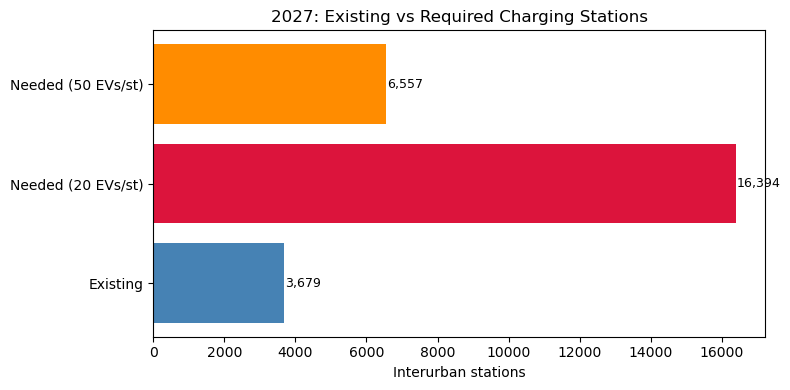

In [89]:
# Existing vs required stations under each utilisation scenario
fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(['Existing', 'Needed (20 EVs/st)', 'Needed (50 EVs/st)'],
        [n_stations, stations_needed_low, stations_needed_high],
        color=['steelblue', 'crimson', 'darkorange'])
ax.set_xlabel('Interurban stations')
ax.set_title('2027: Existing vs Required Charging Stations')
for i, v in enumerate([n_stations, stations_needed_low, stations_needed_high]):
    ax.text(v + 20, i, f'{v:,}', va='center', fontsize=9)
plt.tight_layout()
plt.show()

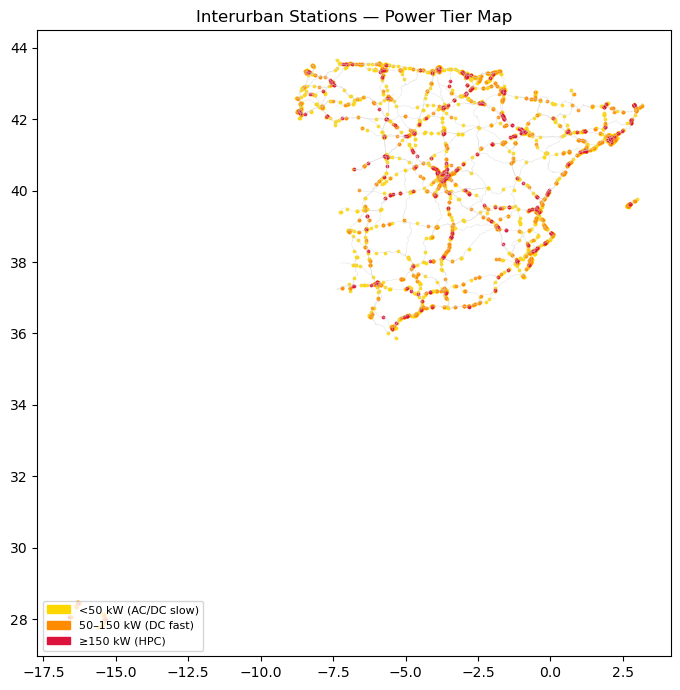

In [90]:
# Interurban stations coloured by power tier — quality gap visualisation
fig, ax = plt.subplots(figsize=(10, 7))
roads.plot(ax=ax, color='lightgrey', linewidth=0.4, alpha=0.6)
for label, color in zip(power_labels, power_colors):
    gdf_interurban[gdf_interurban['power_cat'] == label].plot(
        ax=ax, markersize=3, color=color, alpha=0.8)
handles2 = [mpatches.Patch(color=c, label=l) for l, c in zip(power_labels, power_colors)]
ax.legend(handles=handles2, fontsize=8, loc='lower left')
ax.set_title('Interurban Stations — Power Tier Map')
plt.tight_layout()
plt.show()

**2027 Supply–Demand Gap**

With ~328,000 projected BEVs against only 3,679 existing interurban stations, Spain's current infrastructure implies 89 EVs per station by 2027, roughly two to four times the acceptable utilisation range.

Under a comfortable utilisation benchmark of 20 EVs per station, Spain would need 16,394 stations, leaving a gap of 12,715. The existing network covers only 22% of what is required. Even under a high-utilisation scenario of 50 EVs per station, the shortfall remains substantial at 2,878 additional stations (6,557 needed in total).

The power tier map reinforces that the problem is not only one of quantity but of quality. The network is dominated by slow AC/DC sites below 50 kW, which are unsuitable for interurban travel. HPC sites at or above 150 kW are sparse and concentrated around Madrid and the Mediterranean corridor. This means a significant share of the existing 3,679 stations cannot meaningfully serve the projected EV fleet even at current volumes, making HPC upgrades as urgent as new station deployment.

---
## 6. Grid Capacity — Endesa Distribution Zone

**Source:** Endesa `endesa_demanda_2026_03.csv` — firm available capacity (MW) by substation. Coverage: Andalucía, Cataluña, Aragón, Extremadura, Canarias, Illes Balears (~6 CCAAs).

In [91]:
# Load Endesa substation capacity data and classify grid status
df_raw = pd.read_csv(ENDESA_CSV, sep=';', decimal=',', encoding='utf-8-sig')
df_raw = df_raw.rename(columns={
    'Coordenada UTM X': 'utm_x', 'Coordenada UTM Y': 'utm_y',
    'Nivel de Tensión (kV)': 'kv',
    'Capacidad firme disponible (MW)': 'available_mw',
    'Nombre Subestación': 'nombre', 'Comunidad Autónoma': 'ccaa',
    'Subestación': 'sub_id', 'Provincia.1': 'provincia',
})
for col in ['utm_x','utm_y','kv','available_mw']:
    df_raw[col] = pd.to_numeric(df_raw[col], errors='coerce')

sub = (df_raw.groupby('sub_id').agg(
    utm_x=('utm_x','first'), utm_y=('utm_y','first'),
    nombre=('nombre','first'), ccaa=('ccaa','first'),
    max_kv=('kv','max'), available_mw=('available_mw','max'),
).reset_index().dropna(subset=['utm_x','utm_y']))

t = Transformer.from_crs('EPSG:25830','EPSG:4326', always_xy=True)
sub['longitude'], sub['latitude'] = t.transform(sub['utm_x'].values, sub['utm_y'].values)
valid = sub['longitude'].between(-10,5) & sub['latitude'].between(35,44)
gdf_sub = gpd.GeoDataFrame(
    sub[valid].reset_index(drop=True),
    geometry=gpd.points_from_xy(sub[valid]['longitude'], sub[valid]['latitude']),
    crs='EPSG:4326'
)

# Classify: 1 HPC charger = 0.15 MW; a 10-charger HPC hub = 1.5 MW
def classify(mw):
    if mw <= 0:    return 'Congested'
    elif mw < 1.5: return 'Moderate'
    else:          return 'Sufficient'
gdf_sub['grid_status'] = gdf_sub['available_mw'].apply(classify)

status_counts = gdf_sub['grid_status'].value_counts()
print(f'Substations (mainland): {len(gdf_sub):,}')
print(f'CCAAs covered          : {gdf_sub["ccaa"].nunique()}')
for status, n in status_counts.items():
    print(f'  {status:<12s}: {n:,} ({n/len(gdf_sub)*100:.0f}%)')
print(f'Zero-capacity subs     : {(gdf_sub["available_mw"]==0).sum():,} ({(gdf_sub["available_mw"]==0).mean()*100:.0f}%)')


Substations (mainland): 988
CCAAs covered          : 9
  Congested   : 933 (94%)
  Sufficient  : 49 (5%)
  Moderate    : 6 (1%)
Zero-capacity subs     : 933 (94%)


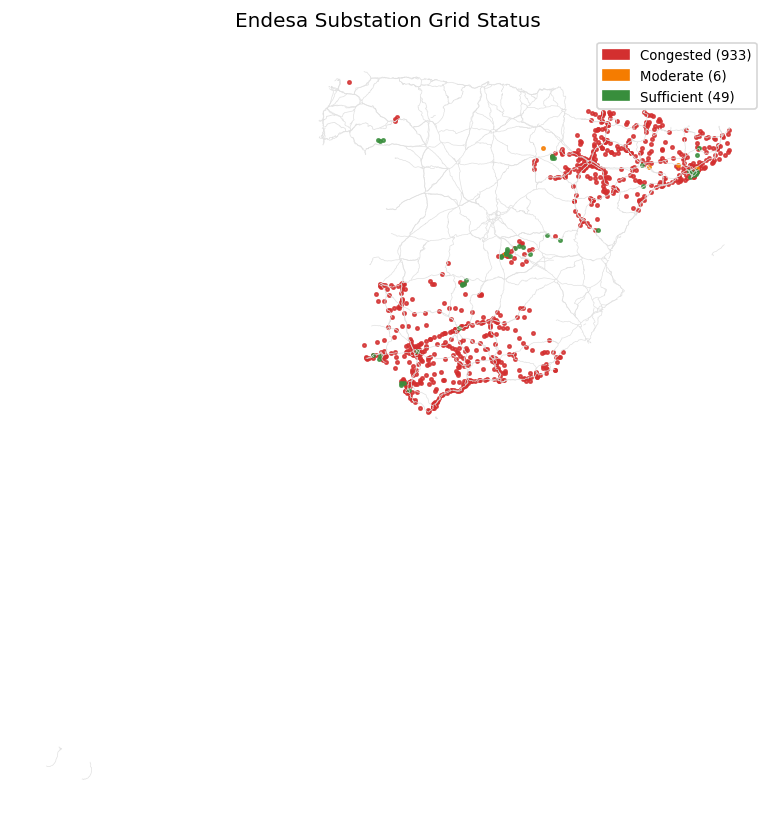

In [92]:
# Endesa substation grid status map overlaid on road network
STATUS_COLORS = {'Congested':'#D32F2F', 'Moderate':'#F57C00', 'Sufficient':'#388E3C'}

fig, ax = plt.subplots(figsize=(10, 7), dpi=120)
roads.plot(ax=ax, color='#E0E0E0', linewidth=0.4)
for status, color in STATUS_COLORS.items():
    gdf_sub[gdf_sub['grid_status']==status].plot(ax=ax, markersize=4, color=color, alpha=0.8)
handles_s = [mpatches.Patch(color=c, label=f'{s} ({status_counts.get(s,0):,})')
             for s, c in STATUS_COLORS.items()]
ax.legend(handles=handles_s, fontsize=8)
ax.set_title('Endesa Substation Grid Status')
ax.axis('off')
plt.tight_layout()
plt.show()

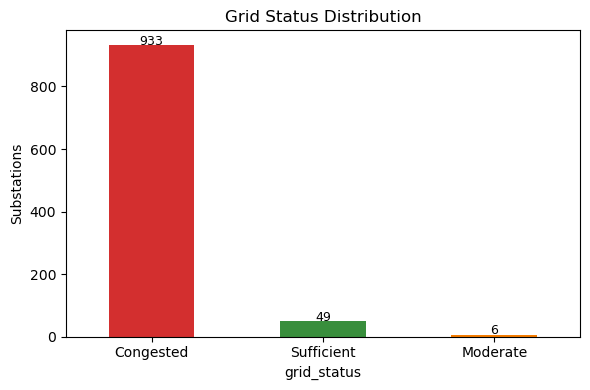

In [93]:
# Distribution of substations by grid status
fig, ax = plt.subplots(figsize=(6, 4))
colors_bar = [STATUS_COLORS[s] for s in status_counts.index]
status_counts.plot(kind='bar', ax=ax, color=colors_bar, rot=0)
ax.set_title('Grid Status Distribution')
ax.set_ylabel('Substations')
for i, v in enumerate(status_counts):
    ax.text(i, v + 1, str(v), ha='center', fontsize=9)
plt.tight_layout()
plt.show()


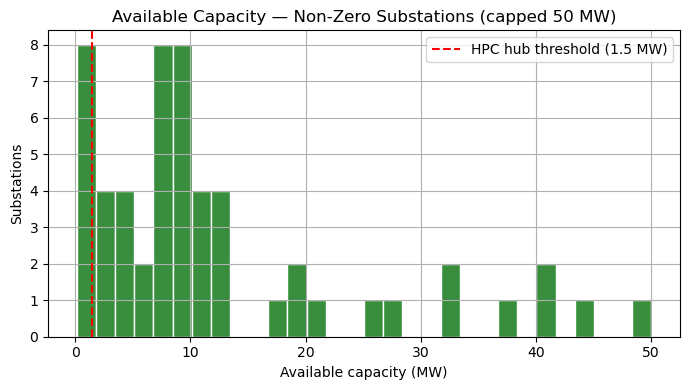

In [94]:
# Available firm capacity among non-congested substations (capped at 50 MW for readability)
fig, ax = plt.subplots(figsize=(7, 4))
gdf_sub[gdf_sub['available_mw'] > 0]['available_mw'].clip(upper=50).hist(
    bins=30, ax=ax, color='#388E3C', edgecolor='white')
ax.axvline(1.5, color='red', ls='--', lw=1.5, label='HPC hub threshold (1.5 MW)')
ax.set_xlabel('Available capacity (MW)')
ax.set_ylabel('Substations')
ax.set_title('Available Capacity — Non-Zero Substations (capped 50 MW)')
ax.legend()
plt.tight_layout()
plt.show()


### Grid Status per Interurban Station

In [95]:
# Spatial join: assign nearest Endesa substation status to each interurban station
gdf_sub_m = gdf_sub.to_crs('EPSG:25830')
gdf_sta_m = gdf_interurban.to_crs('EPSG:25830')

nearest = gpd.sjoin_nearest(
    gdf_sta_m,
    gdf_sub_m[['sub_id','available_mw','grid_status','geometry']],
    how='left', distance_col='dist_to_sub_m'
)
nearest = nearest[~nearest.index.duplicated(keep='first')]
nearest['in_endesa_zone']  = nearest['dist_to_sub_m'] <= 25_000
nearest['assigned_status'] = nearest.apply(
    lambda r: r['grid_status'] if r['in_endesa_zone'] else 'i-DE/Viesgo (no data)', axis=1)

ALL_COLORS     = {**STATUS_COLORS, 'i-DE/Viesgo (no data)': '#9E9E9E'}
status_assigned = nearest['assigned_status'].value_counts()
print('Grid status assigned to interurban stations:')
for status, n in status_assigned.items():
    print(f'  {status:<28s}: {n:,} ({n/len(nearest)*100:.0f}%)')


Grid status assigned to interurban stations:
  i-DE/Viesgo (no data)       : 2,327 (63%)
  Congested                   : 1,245 (34%)
  Sufficient                  : 101 (3%)
  Moderate                    : 6 (0%)


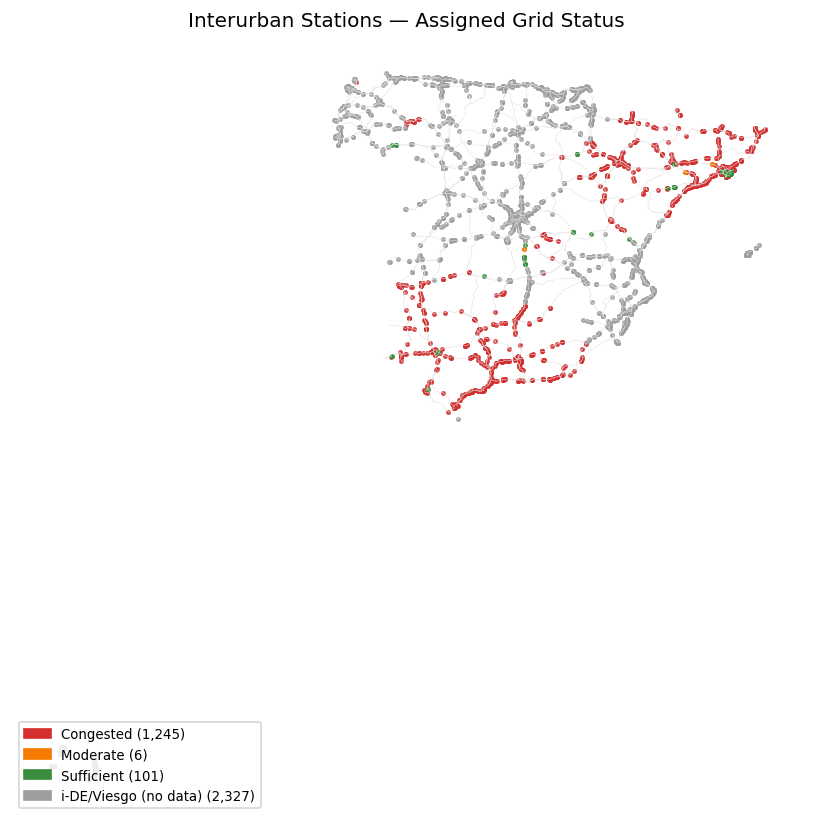

In [96]:
# Map of interurban stations coloured by assigned grid status
fig, ax = plt.subplots(figsize=(10, 7), dpi=120)
roads.plot(ax=ax, color='#E0E0E0', linewidth=0.3)
for status, color in ALL_COLORS.items():
    subset = nearest[nearest['assigned_status'] == status]
    if len(subset):
        gpd.GeoDataFrame(subset, geometry='geometry', crs='EPSG:25830').to_crs('EPSG:4326').plot(
            ax=ax, markersize=4, color=color, alpha=0.8)
handles_a = [mpatches.Patch(color=c, label=f'{s} ({status_assigned.get(s,0):,})')
             for s, c in ALL_COLORS.items() if s in status_assigned]
ax.legend(handles=handles_a, fontsize=8, loc='lower left')
ax.set_title('Interurban Stations — Assigned Grid Status')
ax.axis('off')
plt.tight_layout()
plt.show()

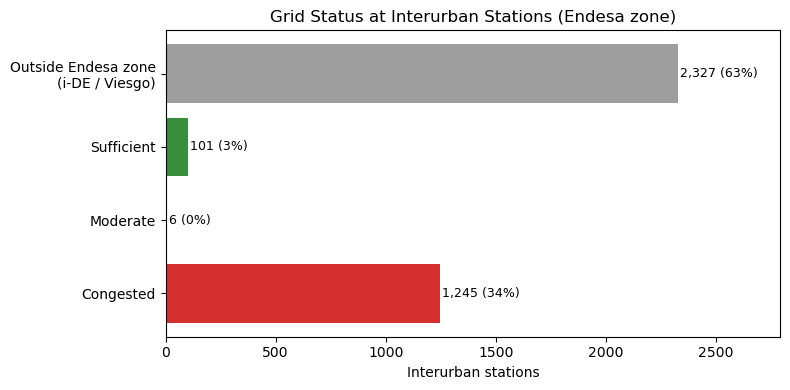

In [ ]:
# Grid status distribution at interurban stations
order  = ['Congested', 'Moderate', 'Sufficient', 'i-DE/Viesgo (no data)']
labels = ['Congested', 'Moderate', 'Sufficient', 'Outside Endesa zone\n(i-DE / Viesgo)']
counts = [status_assigned.get(s, 0) for s in order]
colors = [ALL_COLORS[s] for s in order]

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.barh(labels, counts, color=colors)
ax.set_xlabel('Interurban stations')
ax.set_title('Grid Status at Interurban Stations (Endesa zone)')
for bar, v in zip(bars, counts):
    ax.text(v + 10, bar.get_y() + bar.get_height()/2,
            f'{v:,} ({v/sum(counts)*100:.0f}%)', va='center', fontsize=9)
ax.set_xlim(0, max(counts) * 1.2)
plt.tight_layout()
plt.show()

**Grid Capacity (Endesa Zone)**

The Endesa dataset covers 988 substations across 9 autonomous communities, representing the distributor's service area in Andalucía, Cataluña, Aragón, Extremadura, Canarias, and Baleares. The picture is stark: 94% of substations report zero available firm capacity, classified as Congested. Only 49 substations (5%) have sufficient headroom to support a full HPC hub (≥1.5 MW), and a mere 6 fall in the moderate range. Among the non-zero substations, available capacity is heavily skewed below 10 MW, with a small number of outliers reaching 30–50 MW.

When this grid status is mapped onto the 3,679 interurban charging stations, 63% (2,327 stations) fall outside the Endesa zone entirely, sitting within i-DE (Iberdrola) or Viesgo distribution territory for which no capacity data is available. Of the remaining 1,352 stations in Endesa territory, 1,245 (34% of the total network) are adjacent to a congested substation, meaning grid reinforcement works would be required before any HPC upgrade. Only 101 stations (3%) sit near a substation with sufficient capacity to absorb new load without intervention.

The geographic pattern is equally telling: congestion is concentrated along the Mediterranean corridor, the A-4 southern axis, and around Barcelona, precisely the highest-traffic routes where HPC demand will be greatest. For any new charging hub deployment in Endesa territory, co-planning with the distributor on grid reinforcement is not optional but a prerequisite.

---
## 7. National Grid Context (REE)

**Source:** REE `apidatos.ree.es` — public API, no authentication required.

Spain peninsular electricity demand (REE annual reports):
 year  demand_twh
 2019       263.3
 2020       250.4
 2021       259.1
 2022       251.3
 2023       243.0


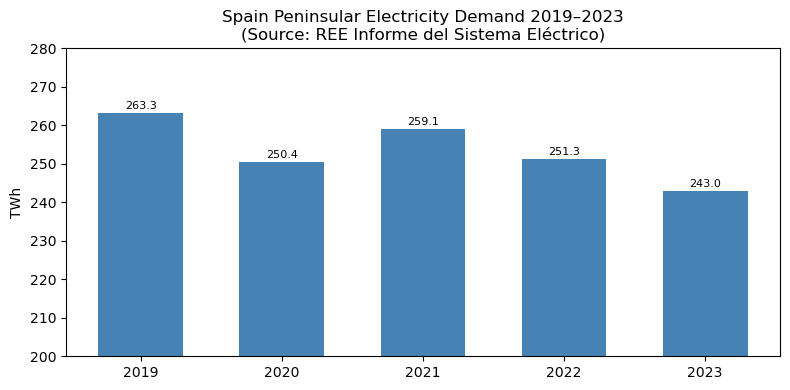

In [49]:
# Source: REE — Informe del Sistema Eléctrico Español (annual reports)
# https://www.ree.es/es/datos/publicaciones/informe-anual-sistema/informe-del-sistema-electrico-espanol-2023

ree_demand = pd.DataFrame({
    'year': [2019, 2020, 2021, 2022, 2023],
    'demand_twh': [263.3, 250.4, 259.1, 251.3, 243.0],  # peninsular demand
})

print('Spain peninsular electricity demand (REE annual reports):')
print(ree_demand.to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(ree_demand['year'], ree_demand['demand_twh'], color='steelblue', width=0.6)
ax.set_ylabel('TWh')
ax.set_ylim(200, 280)
ax.set_title('Spain Peninsular Electricity Demand 2019–2023\n(Source: REE Informe del Sistema Eléctrico)')
for i, row in ree_demand.iterrows():
    ax.text(row['year'], row['demand_twh'] + 1, f"{row['demand_twh']:.1f}", ha='center', fontsize=8)
plt.tight_layout()
plt.show()

**National Grid Impact**

Spain's peninsular electricity demand declined from 263.3 TWh in 2019 to 243.0 TWh in 2023, a cumulative drop of roughly 8%. The 2020 dip reflects COVID-related industrial slowdown, while the sustained decline from 2021 onwards points to improving energy efficiency and structural shifts in industrial consumption rather than economic contraction.

This national demand baseline is the reference against which EV charging load will be assessed in the following cell. At ~243 TWh, the scale of the national grid makes it unlikely that EV adoption at the projected levels would constitute a meaningful macro-level stress, shifting the analytical focus to local distribution constraints as examined in Section 6.

---
## 8. Key Findings Summary

This analysis spans Spain's entire interurban EV charging ecosystem across four datasets, from road infrastructure and existing charging sites to fleet projections and grid capacity. The findings converge on a single conclusion: **Spain's charging infrastructure gap by 2027 is primarily a quality and grid problem, not a geographic coverage problem.**

Spain's 29,050 km interurban network is already well served geographically, with **99.6% of roads falling within 50 km of an existing station**. However, of the 3,679 interurban stations, only **590 (16%) meet the HPC threshold of 150 kW or above**. The vast majority are slow AC chargers unsuitable for interurban travel, meaning the effective usable network is a fraction of what the headline count suggests.

On the demand side, Spain's BEV fleet is projected to reach **~328,000 vehicles by 2027**, implying **89 EVs per existing station**, four times the comfortable utilisation benchmark. Closing this gap requires between **2,878 and 12,715 additional interurban stations** depending on target utilisation, with HPC upgrades at existing sites being the more urgent priority.

Grid capacity is the binding constraint on deployment. In Endesa's territory alone, **94% of substations (933 out of 988) report zero available firm capacity**, and 34% of all interurban stations sit adjacent to a congested substation. Critically, EV charging load at projected 2027 volumes adds only **0.30% to national electricity demand**, confirming the constraint is local distribution, not national generation.

| KPI | Value | Note |
|---|---|---|
| M1 Eligible road network | 29,050 km | 1,535 segments |
| M2 National charging sites | 12,074 | Pre-filter |
| M2 Interurban sites (≤500 m) | 3,679 | 30% of national |
| M2 HPC sites (≥150 kW) | 590 | 16% of interurban |
| M2 Road coverage | 99.6% | ≤50 km to nearest station |
| M3 BEV fleet 2027 (logistic model) | 327,883 | Central estimate |
| M3 EVs per existing station 2027 | 89 | 4× comfortable benchmark |
| Gap Additional stations needed | 2,878 – 12,715 | 20–50 EVs/station benchmark |
| Grid Congested substations (Endesa) | 933 / 988 | 94% |
| REE EV load as % national demand | 0.30% | Local, not national constraint |


### Outputs for the Modelling Team

| File | Contents |
|---|---|
| `Data/interim/m2_charging_sites_interurban.csv` | 3,679 interurban stations with road assignment and power tier |
| `Data/interim/m2_road_coverage.csv` | Distance to nearest station per road segment |
| `Data/processed/m3_ev_projection.json` | Logistic model fleet projection + annual forecast 2024–2027 |
| `Data/external/grid_capacity_endesa/` | Substation-level firm capacity (Endesa zone, 988 substations) |